<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT007e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running γ=0.05, ε=0.01...
Running γ=0.05, ε=0.03...
Running γ=0.05, ε=0.05...
Running γ=0.05, ε=0.07...
Running γ=0.05, ε=0.1...
Running γ=0.08, ε=0.01...
Running γ=0.08, ε=0.03...
Running γ=0.08, ε=0.05...
Running γ=0.08, ε=0.07...
Running γ=0.08, ε=0.1...
Running γ=0.1, ε=0.01...
Running γ=0.1, ε=0.03...
Running γ=0.1, ε=0.05...
Running γ=0.1, ε=0.07...
Running γ=0.1, ε=0.1...
Running γ=0.15, ε=0.01...
Running γ=0.15, ε=0.03...
Running γ=0.15, ε=0.05...
Running γ=0.15, ε=0.07...
Running γ=0.15, ε=0.1...
Running γ=0.2, ε=0.01...
Running γ=0.2, ε=0.03...
Running γ=0.2, ε=0.05...
Running γ=0.2, ε=0.07...
Running γ=0.2, ε=0.1...


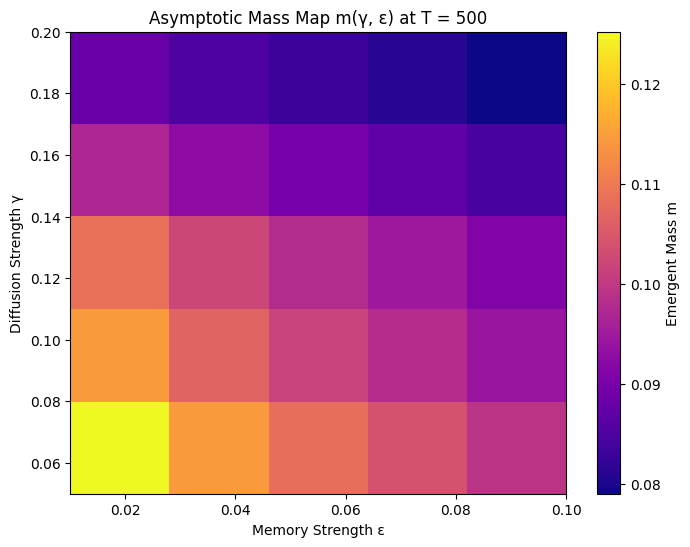

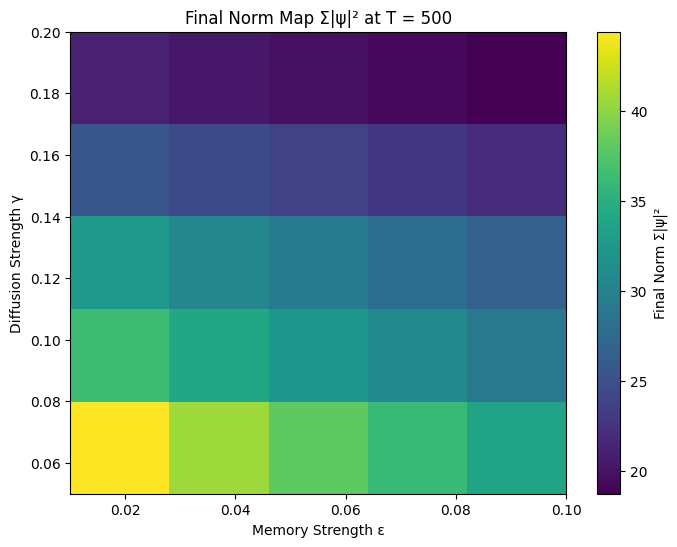

In [1]:
# QFT007e: Asymptotic Mass Fidelity Scan — T = 500
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
N = 100
T = 500
A = 1.0
sigma = 5.0
gamma_vals = [0.05, 0.08, 0.10, 0.15, 0.20]
epsilon_vals = [0.01, 0.03, 0.05, 0.07, 0.10]

mass_map = np.zeros((len(gamma_vals), len(epsilon_vals)))
norm_map = np.zeros((len(gamma_vals), len(epsilon_vals)))

def decay_func(r, a, lambda_c):
    return a * np.exp(-r / lambda_c)

def run_simulation(gamma, epsilon):
    x0, y0 = N//2, N//2
    X, Y = np.meshgrid(np.arange(N), np.arange(N))
    psi = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) + 1j * np.zeros((N, N))

    for t in range(T):
        psi_new = np.copy(psi)
        for i in range(N):
            for j in range(N):
                ip, im = (i+1)%N, (i-1)%N
                jp, jm = (j+1)%N, (j-1)%N

                laplacian = (
                    (psi[ip,j] + psi[im,j] + psi[i,jp] + psi[i,jm]) / 6 +
                    (psi[ip,jp] + psi[ip,jm] + psi[im,jp] + psi[im,jm]) / 12 -
                    psi[i,j]
                )
                diffusion = gamma * laplacian

                delta_A2 = (
                    np.abs(psi[ip,j])**2 + np.abs(psi[im,j])**2 - 2 * np.abs(psi[i,j])**2
                )
                compensation = epsilon * delta_A2

                psi_new[i,j] = psi[i,j] + diffusion + compensation
        psi = psi_new

    magnitude = np.abs(psi)**2
    norm = np.sum(magnitude)

    radii = []
    values = []
    for r in range(1, N//2):
        shell = magnitude[x0-r:x0+r+1, y0-r:y0+r+1]
        shell_mean = np.mean(shell)
        radii.append(r)
        values.append(shell_mean)

    try:
        params, _ = curve_fit(decay_func, radii, values, p0=(1.0, 10.0))
        lambda_c = params[1]
        mass = 1 / lambda_c
    except:
        mass = np.nan

    return mass, norm

# Run full scan
for i, gamma in enumerate(gamma_vals):
    for j, epsilon in enumerate(epsilon_vals):
        print(f"Running γ={gamma}, ε={epsilon}...")
        mass, norm = run_simulation(gamma, epsilon)
        mass_map[i, j] = mass
        norm_map[i, j] = norm

# Plot mass map
plt.figure(figsize=(8, 6))
plt.imshow(mass_map, cmap='plasma', origin='lower',
           extent=[min(epsilon_vals), max(epsilon_vals), min(gamma_vals), max(gamma_vals)],
           aspect='auto')
plt.colorbar(label='Emergent Mass m')
plt.xlabel('Memory Strength ε')
plt.ylabel('Diffusion Strength γ')
plt.title('Asymptotic Mass Map m(γ, ε) at T = 500')
plt.show()

# Plot norm map
plt.figure(figsize=(8, 6))
plt.imshow(norm_map, cmap='viridis', origin='lower',
           extent=[min(epsilon_vals), max(epsilon_vals), min(gamma_vals), max(gamma_vals)],
           aspect='auto')
plt.colorbar(label='Final Norm Σ|ψ|²')
plt.xlabel('Memory Strength ε')
plt.ylabel('Diffusion Strength γ')
plt.title('Final Norm Map Σ|ψ|² at T = 500')
plt.show()
